# Kalman Filter Analysis

This notebook analyzes filtering results for stochastic volatility model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set plotting style
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

In [2]:
# Load experiment results
base_dir = Path('../outputs/stochastic_volatility')

ekf_dir = base_dir / 'stochastic_volatility_ekf'
ukf_dir = base_dir / 'stochastic_volatility_ukf'

# Load EKF results
ekf_states = np.load(ekf_dir / 'states.npy')
ekf_means = np.load(ekf_dir / 'means.npy')
ekf_covs = np.load(ekf_dir / 'covs.npy')
ekf_obs = np.load(ekf_dir / 'observations.npy')

# Load UKF results
ukf_states = np.load(ukf_dir / 'states.npy')
ukf_means = np.load(ukf_dir / 'means.npy')
ukf_covs = np.load(ukf_dir / 'covs.npy')
ukf_obs = np.load(ukf_dir / 'observations.npy')

print(f"States shape: {ekf_states.shape}")
print(f"Means shape: {ekf_means.shape}")
print(f"Covs shape: {ekf_covs.shape}")
print(f"Observations shape: {ekf_obs.shape}")

States shape: (500, 1)
Means shape: (500, 1)
Covs shape: (500, 1, 1)
Observations shape: (500, 1)


In [3]:
def plot_filter_results(states, means, covs, observations, filter_name, color='blue', ax=None):
    """
    Plot filtering results with true state, observations, filtered means, and 2-sigma band.
    
    Parameters:
    -----------
    states : ndarray, shape (T, state_dim)
        True states
    means : ndarray, shape (T, state_dim)
        Filtered means
    covs : ndarray, shape (T, state_dim, state_dim)
        Filtered covariances
    observations : ndarray, shape (T, obs_dim)
        Observations
    filter_name : str
        Name of the filter (e.g., 'EKF', 'UKF')
    color : str
        Color for the estimate and confidence band
    ax : matplotlib axis, optional
        If provided, plot on this axis. Otherwise create new figure.
    
    Returns:
    --------
    ax : matplotlib axis
    """
    T = len(states)
    time_steps = np.arange(T)
    
    # Compute 2-sigma bounds (using first state dimension)
    std = np.sqrt(covs[:, 0, 0])
    upper = means[:, 0] + 2 * std
    lower = means[:, 0] - 2 * std
    
    # Create figure if no axis provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot true state
    ax.plot(time_steps, states[:, 0], 'k-', linewidth=2, label='True State', alpha=0.8)
    
    # Plot observations
    ax.scatter(time_steps, observations[:, 0], c='gray', s=20, alpha=0.5, 
               label='Observations', marker='x')
    
    # Plot filtered means
    ax.plot(time_steps, means[:, 0], '-', color=color, linewidth=1.5, 
            label=f'{filter_name} Estimate')
    
    # Plot 2-sigma confidence band
    ax.fill_between(time_steps, lower, upper, alpha=0.3, color=color, 
                     label='2-σ Confidence Band')
    
    ax.set_xlabel('Time Step')
    ax.set_ylabel('State')
    ax.set_title(f'{filter_name} - Stochastic Volatility Model')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    return ax

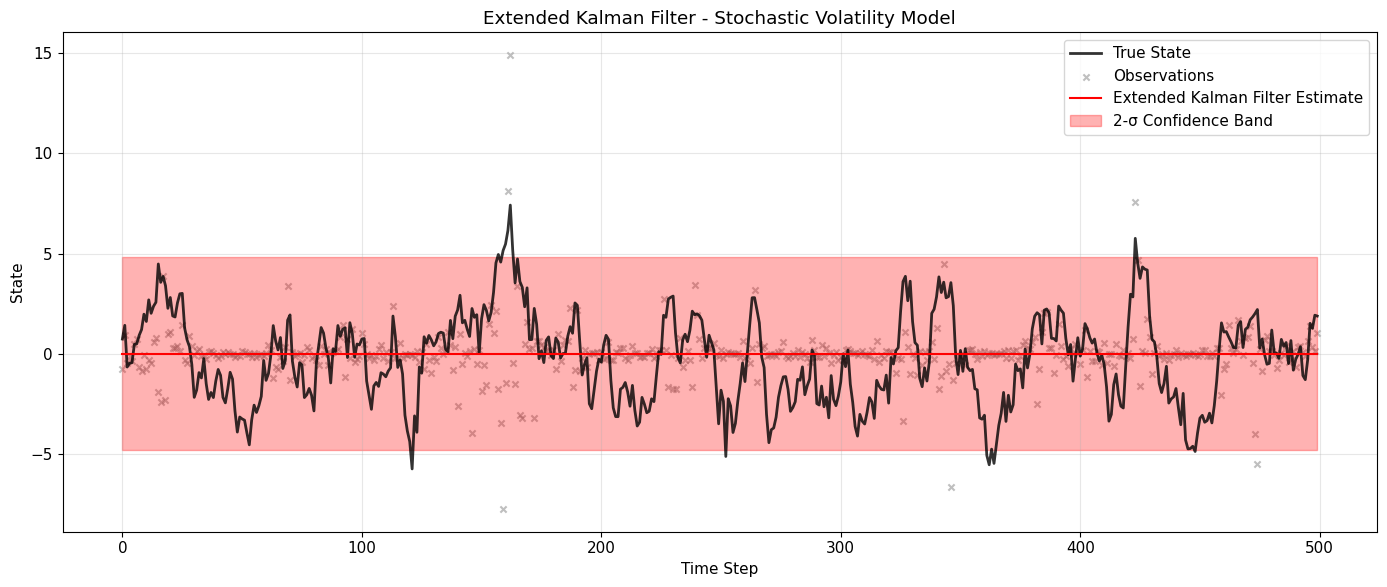

In [4]:
# Plot EKF results
plot_filter_results(ekf_states, ekf_means, ekf_covs, ekf_obs, 
                    filter_name='Extended Kalman Filter', color='red')
plt.tight_layout()
plt.show()

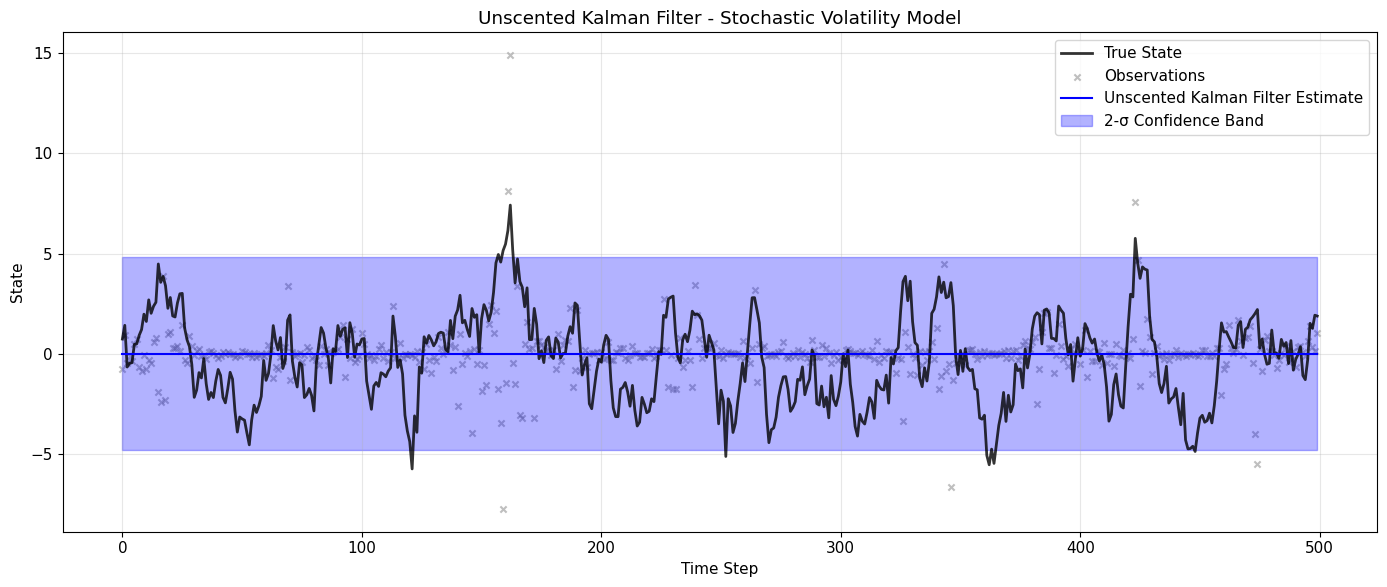

In [5]:
# Plot UKF results
plot_filter_results(ukf_states, ukf_means, ukf_covs, ukf_obs, 
                    filter_name='Unscented Kalman Filter', color='blue')
plt.tight_layout()
plt.show()

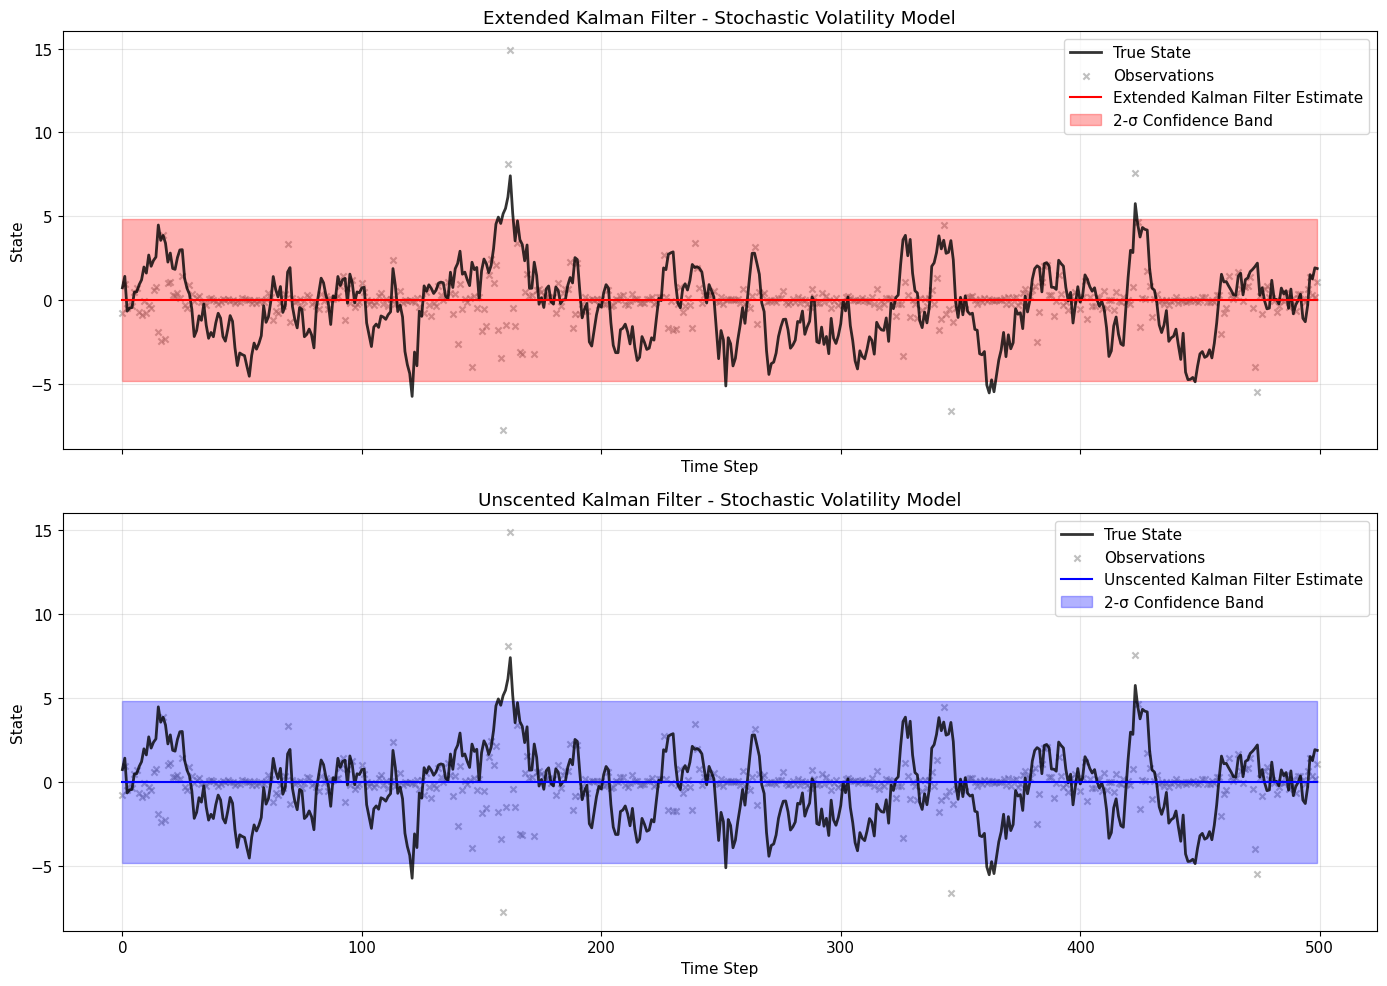

In [7]:
# Comparison plot: EKF vs UKF
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot EKF
plot_filter_results(ekf_states, ekf_means, ekf_covs, ekf_obs, 
                    filter_name='Extended Kalman Filter', color='red', ax=axes[0])

# Plot UKF
plot_filter_results(ukf_states, ukf_means, ukf_covs, ukf_obs, 
                    filter_name='Unscented Kalman Filter', color='blue', ax=axes[1])

plt.tight_layout()
plt.savefig('sto_uekf1.png', dpi=300, bbox_inches='tight')
plt.show()

# Range-Bearing Model Analysis

In [18]:
# Load range_bearing experiment results
rb_base_dir = Path('../outputs/range_bearing')

rb_ekf_dir = rb_base_dir / 'range_bearing_ekf'
rb_ukf_dir = rb_base_dir / 'range_bearing_ukf'

# Load EKF results
rb_ekf_states = np.load(rb_ekf_dir / 'states.npy')
rb_ekf_means = np.load(rb_ekf_dir / 'means.npy')
rb_ekf_covs = np.load(rb_ekf_dir / 'covs.npy')
rb_ekf_obs = np.load(rb_ekf_dir / 'observations.npy')

# Load UKF results
rb_ukf_states = np.load(rb_ukf_dir / 'states.npy')
rb_ukf_means = np.load(rb_ukf_dir / 'means.npy')
rb_ukf_covs = np.load(rb_ukf_dir / 'covs.npy')
rb_ukf_obs = np.load(rb_ukf_dir / 'observations.npy')

print(f"States shape: {rb_ekf_states.shape}")
print(f"Means shape: {rb_ekf_means.shape}")
print(f"Covs shape: {rb_ekf_covs.shape}")
print(f"Observations shape: {rb_ekf_obs.shape}")

States shape: (100, 2)
Means shape: (100, 2)
Covs shape: (100, 2, 2)
Observations shape: (100, 2)


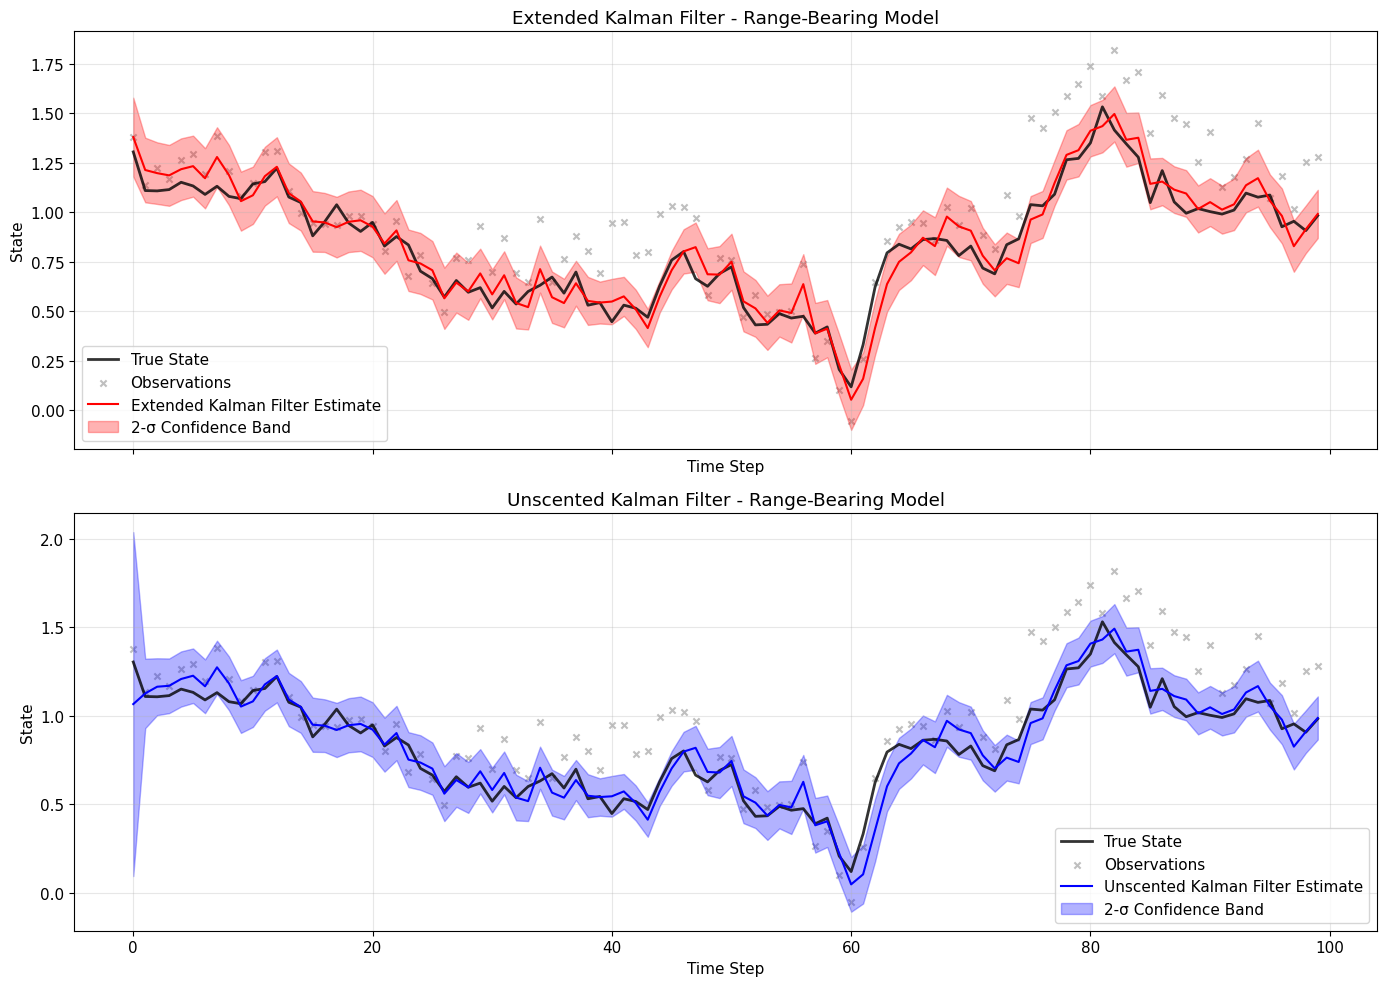

In [20]:
# Comparison plot: EKF vs UKF for Range-Bearing Model
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot EKF
plot_filter_results(rb_ekf_states, rb_ekf_means, rb_ekf_covs, rb_ekf_obs, 
                    filter_name='Extended Kalman Filter', color='red', ax=axes[0])
axes[0].set_title('Extended Kalman Filter - Range-Bearing Model')

# Plot UKF
plot_filter_results(rb_ukf_states, rb_ukf_means, rb_ukf_covs, rb_ukf_obs, 
                    filter_name='Unscented Kalman Filter', color='blue', ax=axes[1])
axes[1].set_title('Unscented Kalman Filter - Range-Bearing Model')

plt.tight_layout()
plt.savefig('rb_uekf1.png', dpi=300, bbox_inches='tight')

plt.show()